# 06 Parameter Sweeps and Interpretation

This notebook asks which assumptions make gaze matter. It runs compact sweeps over RF size, retinotopic jitter, SNR, and mapping error, then summarizes how grating `|ΔPO|` and natural-image response instability change together.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.utils import load_config
from src.simulation import run_sweep
from src.plotting import set_plot_style, plot_summary_bars

set_plot_style()
fig_dir = ROOT / 'results/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

configs = [
    ROOT / 'configs/default.yaml', ROOT / 'configs/broad_rf.yaml', ROOT / 'configs/narrow_rf.yaml',
    ROOT / 'configs/low_jitter.yaml', ROOT / 'configs/high_jitter.yaml',
    ROOT / 'configs/low_snr.yaml', ROOT / 'configs/high_snr.yaml',
    ROOT / 'configs/mapping_error_none.yaml', ROOT / 'configs/mapping_error_small.yaml', ROOT / 'configs/mapping_error_medium.yaml'
]
summary = run_sweep(load_config(ROOT / 'configs/default.yaml', debug=True), configs, debug=True)
display(summary[['condition', 'median_abs_delta_po_deg', 'population_response_correlation', 'rdm_similarity_to_baseline', 'median_relative_response_change']].round(3))

,condition,median_abs_delta_po_deg,population_response_correlation,rdm_similarity_to_baseline,median_relative_response_change
0,default,9.486,-0.009,0.411,1.061
1,broad_rf,16.021,0.167,0.590,1.013
2,narrow_rf,9.310,0.187,0.348,0.974
3,low_jitter,11.826,0.058,-0.089,0.944
4,high_jitter,11.616,0.179,0.730,0.987
5,low_snr,13.473,0.248,0.178,0.917
6,high_snr,8.831,0.156,0.252,1.070
7,mapping_error_none,11.469,0.163,0.298,1.090
8,mapping_error_small,10.934,0.169,0.764,1.097
9,mapping_error_medium,10.518,0.083,0.472,1.029


## Sweep Summary Panels

Bar plots are useful for comparing conditions, while the scatter plot asks whether grating sensitivity predicts natural-image sensitivity.

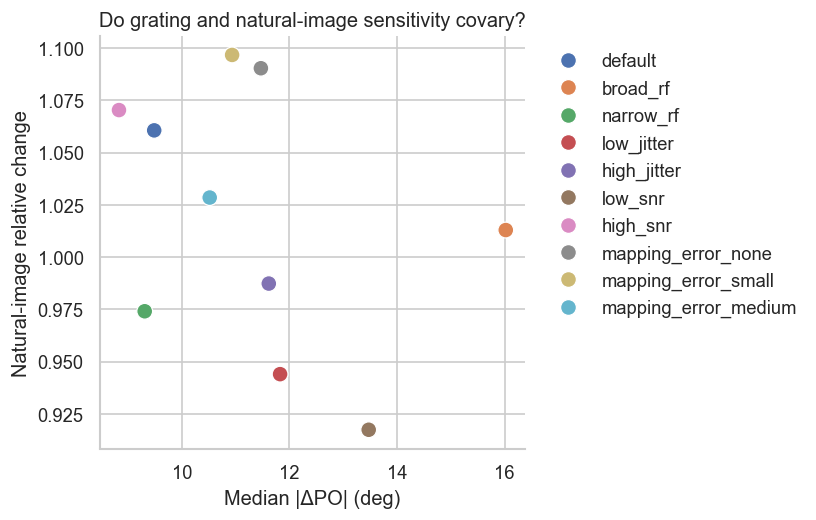

In [2]:
plot_summary_bars(summary, fig_dir / 'notebook06_sweep_bars.png')
plt.figure(figsize=(7,4.5))
sns.scatterplot(data=summary, x='median_abs_delta_po_deg', y='median_relative_response_change', hue='condition', s=90)
plt.xlabel('Median |ΔPO| (deg)')
plt.ylabel('Natural-image relative change')
plt.title('Do grating and natural-image sensitivity covary?')
plt.legend(frameon=False, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook06_sweep_bridge.png', bbox_inches='tight')

## Ranked Conditions

The ranked tables make the interpretation concrete. High `|ΔPO|` does not always mean the natural-image representation is the least stable, because the stimulus classes probe different aspects of the RF model.

In [3]:
display(summary.sort_values('median_abs_delta_po_deg', ascending=False)[['condition', 'median_abs_delta_po_deg', 'p90_abs_delta_po_deg', 'median_tuning_strength_change']].round(3))
display(summary.sort_values('population_response_correlation')[['condition', 'population_response_correlation', 'rdm_similarity_to_baseline', 'median_relative_response_change']].round(3))

,condition,median_abs_delta_po_deg,p90_abs_delta_po_deg,median_tuning_strength_change
1,broad_rf,16.021,53.351,-0.016
5,low_snr,13.473,59.400,0.019
3,low_jitter,11.826,35.572,0.010
4,high_jitter,11.616,40.348,-0.004
7,mapping_error_none,11.469,33.863,-0.001
8,mapping_error_small,10.934,32.209,0.009
9,mapping_error_medium,10.518,28.646,-0.010
0,default,9.486,37.275,-0.007
2,narrow_rf,9.310,26.647,0.000
6,high_snr,8.831,33.469,0.017


,condition,population_response_correlation,rdm_similarity_to_baseline,median_relative_response_change
0,default,-0.009,0.411,1.061
3,low_jitter,0.058,-0.089,0.944
9,mapping_error_medium,0.083,0.472,1.029
6,high_snr,0.156,0.252,1.070
7,mapping_error_none,0.163,0.298,1.090
1,broad_rf,0.167,0.590,1.013
8,mapping_error_small,0.169,0.764,1.097
4,high_jitter,0.179,0.730,0.987
2,narrow_rf,0.187,0.348,0.974
5,low_snr,0.248,0.178,0.917


## Interpretation Checklist

- Gaze should matter little for grating PO when responses are phase-invariant, phases are densely averaged, mapping is accurate, SNR is high, RFs are broad, and preferred SFs are low.
- Gaze should matter more for grating PO when RFs are narrow, preferred SFs are higher, simple-cell phase sensitivity is sampled sparsely, mapping is imperfect, or PO estimates are noisy.
- Gaze can affect natural-image responses even when grating PO is stable, because image translation changes local luminance structure over RF subfields.
- Mapping errors matter when their displacement approaches RF subfield scale.
- SNR dominates when bootstrap PO uncertainty is large even without deterministic geometry changes.

Final answer for this null model: grating `ΔPO` is mainly a phase-sensitive estimation phenomenon, while natural-image instability reflects direct translation of structured image content across RFs. The comparison is most interpretable when the phase-sanity, mapping-error, and SNR controls are checked first.

## Weekly Drift Hypotheses

This section separates four explanations for longitudinal change relative to a reference session: gaze only, gaze plus slightly wrong spherical correction, circuit drift only, and gaze plus circuit drift. The key question is whether the measured correlation between cumulative gaze drift and similarity loss is already expected from optics and registration, or whether a latent neural-state drift is still needed.

In [6]:
import pandas as pd
from IPython.display import Image, display

longitudinal = pd.read_csv(ROOT / 'results/tables/longitudinal_hypothesis_summary.csv')
latest = longitudinal.sort_values('weeks_from_reference').groupby('condition').tail(1)
display(
    latest[[
        'condition',
        'measured_gaze_deg',
        'static_grating_median_abs_delta_po_deg',
        'moving_grating_median_abs_delta_po_deg',
        'natural_population_response_correlation',
        'natural_rdm_similarity_to_baseline',
        'circuit_drift_amplitude_deg',
        'mapping_error_name',
    ]].round(3).sort_values('natural_population_response_correlation')
)

corr_rows = []
for condition, group in longitudinal.groupby('condition'):
    corr_rows.append(
        {
            'condition': condition,
            'static_grating_corr_with_measured_gaze': group['static_grating_median_abs_delta_po_deg'].corr(group['measured_gaze_deg']),
            'moving_grating_corr_with_measured_gaze': group['moving_grating_median_abs_delta_po_deg'].corr(group['measured_gaze_deg']),
            'natural_corr_with_measured_gaze': group['natural_population_response_correlation'].corr(group['measured_gaze_deg']),
            'natural_rdm_corr_with_measured_gaze': group['natural_rdm_similarity_to_baseline'].corr(group['measured_gaze_deg']),
        }
    )
display(pd.DataFrame(corr_rows).round(3).sort_values('natural_corr_with_measured_gaze'))

,condition,measured_gaze_deg,static_grating_median_abs_delta_po_deg,moving_grating_median_abs_delta_po_deg,natural_population_response_correlation,natural_rdm_similarity_to_baseline,circuit_drift_amplitude_deg,mapping_error_name
9,gaze_plus_mapping_error,4.0,6.724,0.981,0.398,0.824,0.0,slight
19,gaze_plus_circuit_drift,4.0,7.395,2.167,0.404,0.833,4.0,perfect
4,gaze_only,4.0,6.359,0.945,0.409,0.822,0.0,perfect
14,circuit_drift_only,4.0,4.131,1.929,0.981,0.998,4.0,perfect


,condition,static_grating_corr_with_measured_gaze,moving_grating_corr_with_measured_gaze,natural_corr_with_measured_gaze,natural_rdm_corr_with_measured_gaze
1,gaze_only,0.997,0.765,-0.985,-0.992
3,gaze_plus_mapping_error,0.992,0.803,-0.985,-0.992
2,gaze_plus_circuit_drift,0.999,0.983,-0.983,-0.992
0,circuit_drift_only,0.999,0.989,-0.960,-0.957


## How To Read The Weekly Plots

Use the weekly panels to ask three separate questions. First, do static and moving gratings stay relatively stable while natural-image similarity falls with gaze? Second, does adding a small mapping error reproduce the observed slope more closely than gaze alone? Third, if the circuit-drift conditions are required to match the trajectory, then gaze and spherical correction are not sufficient on their own.

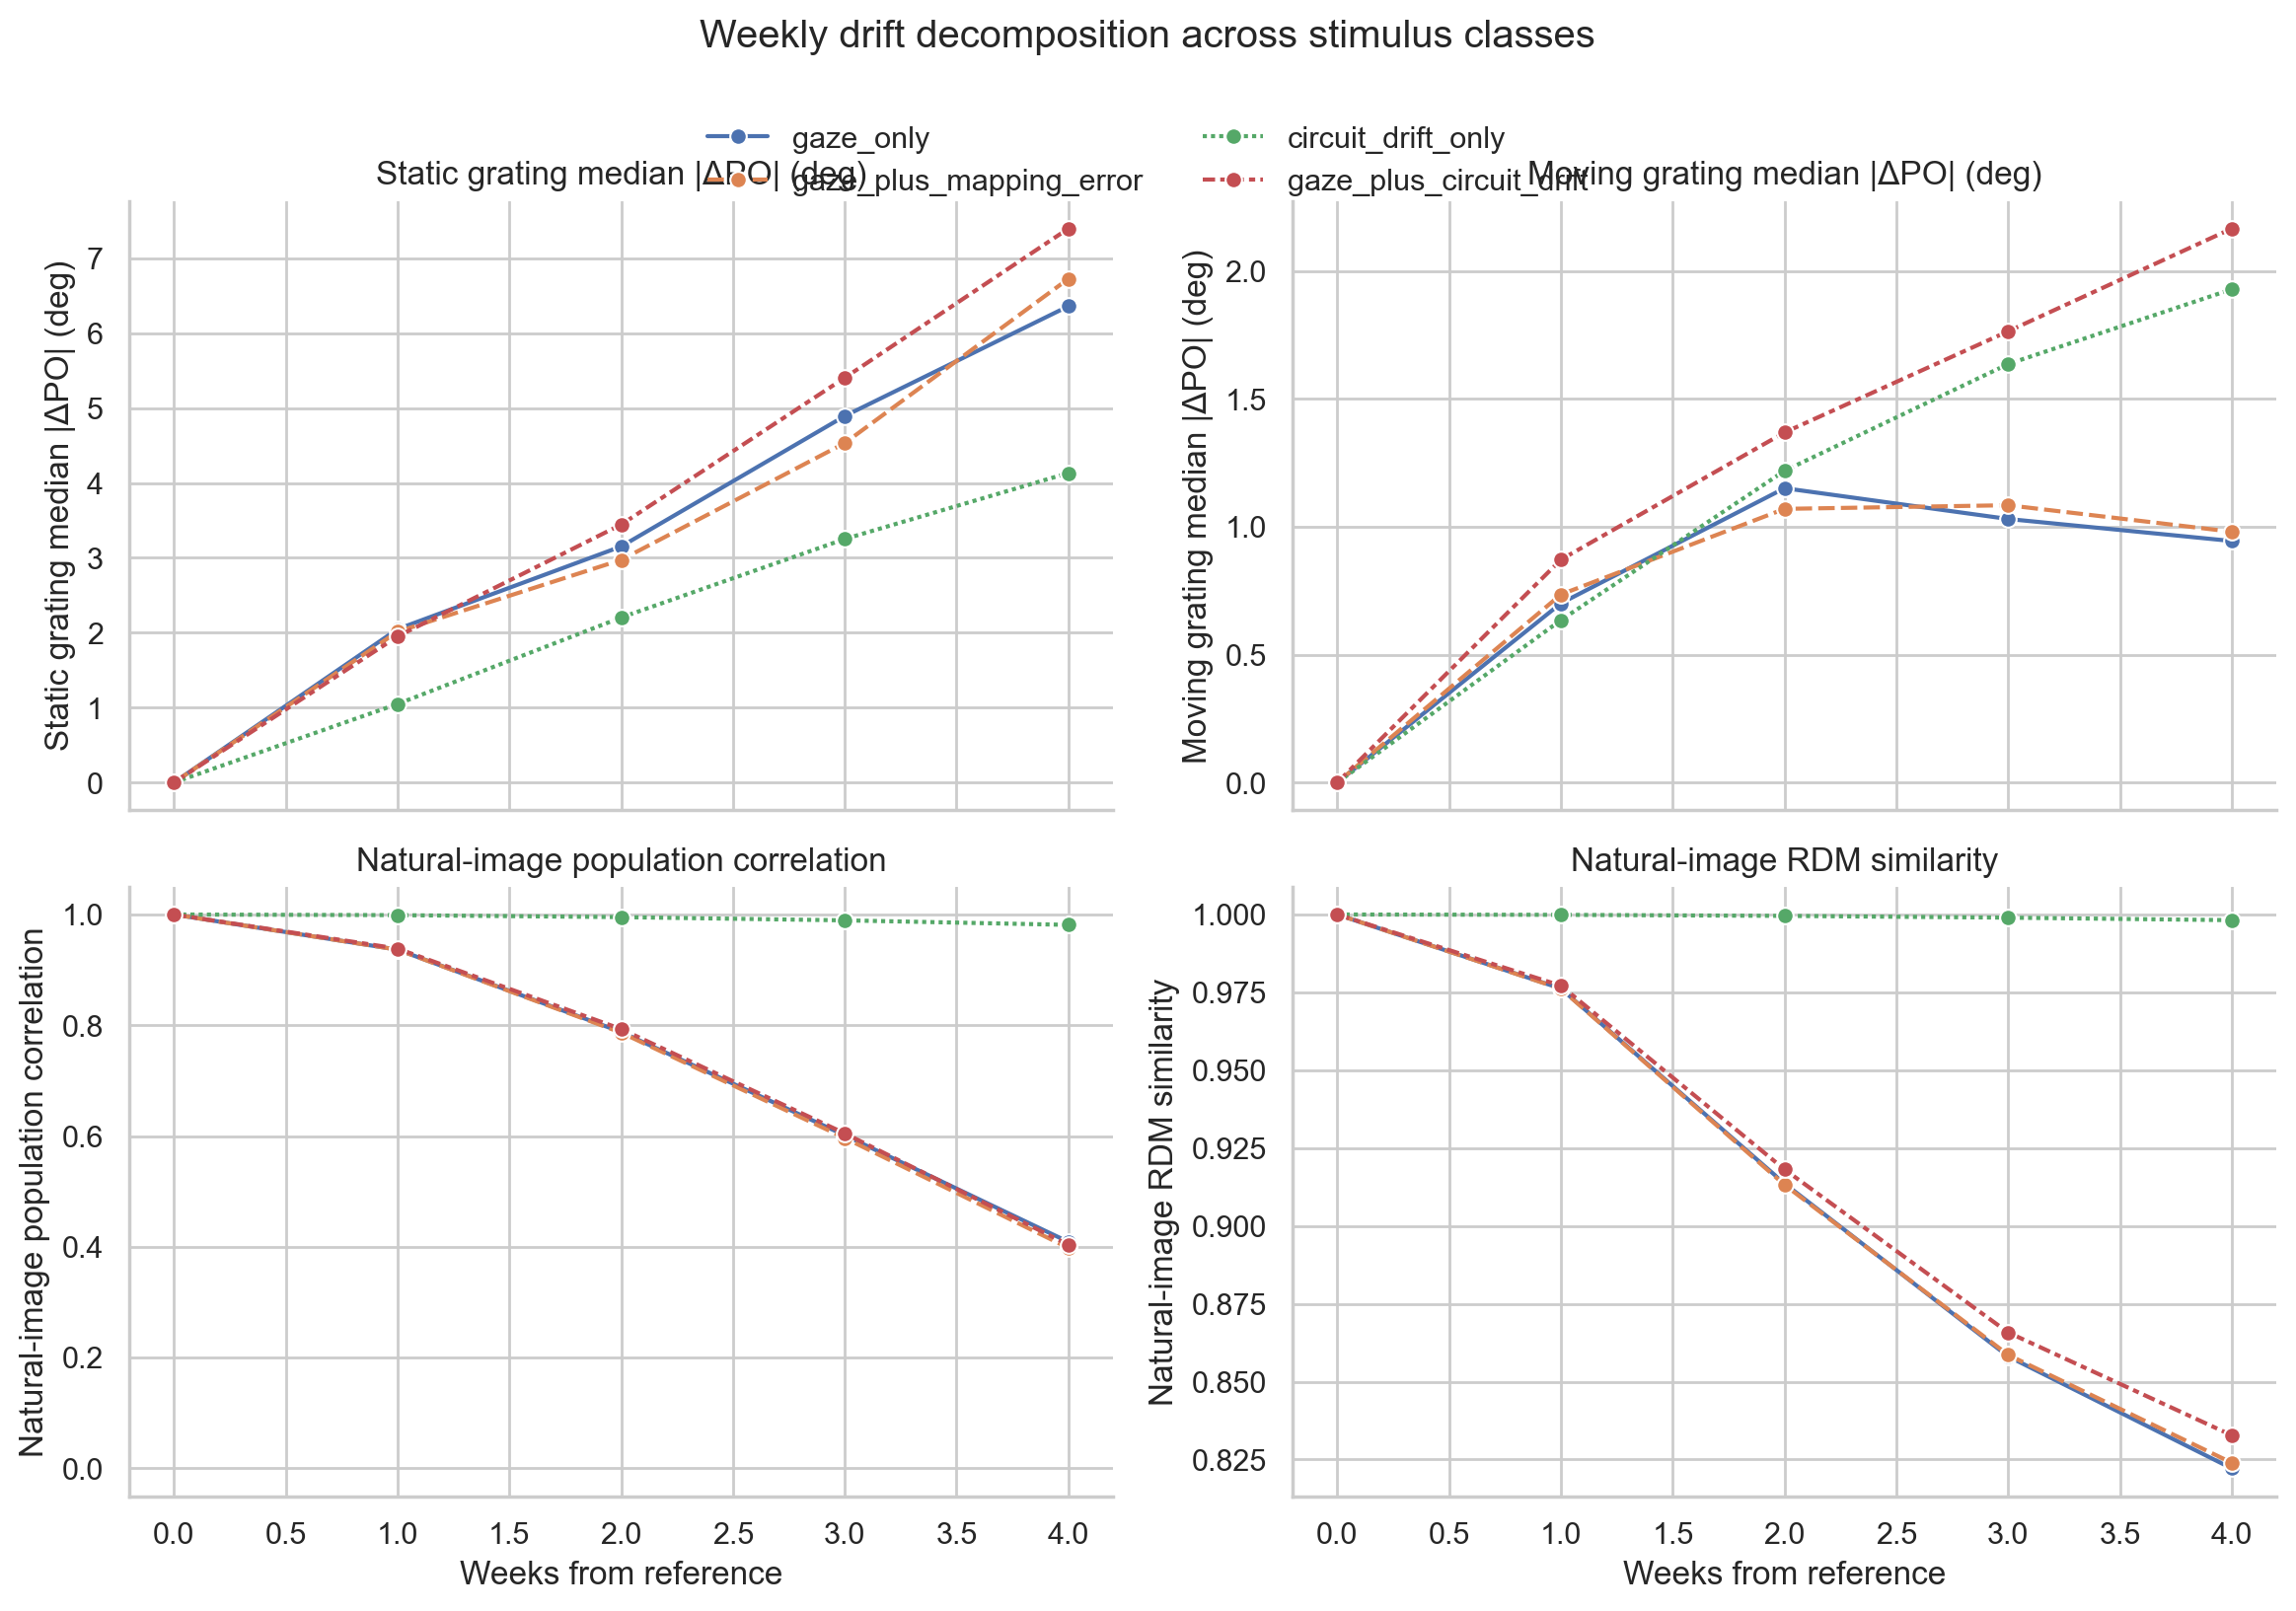

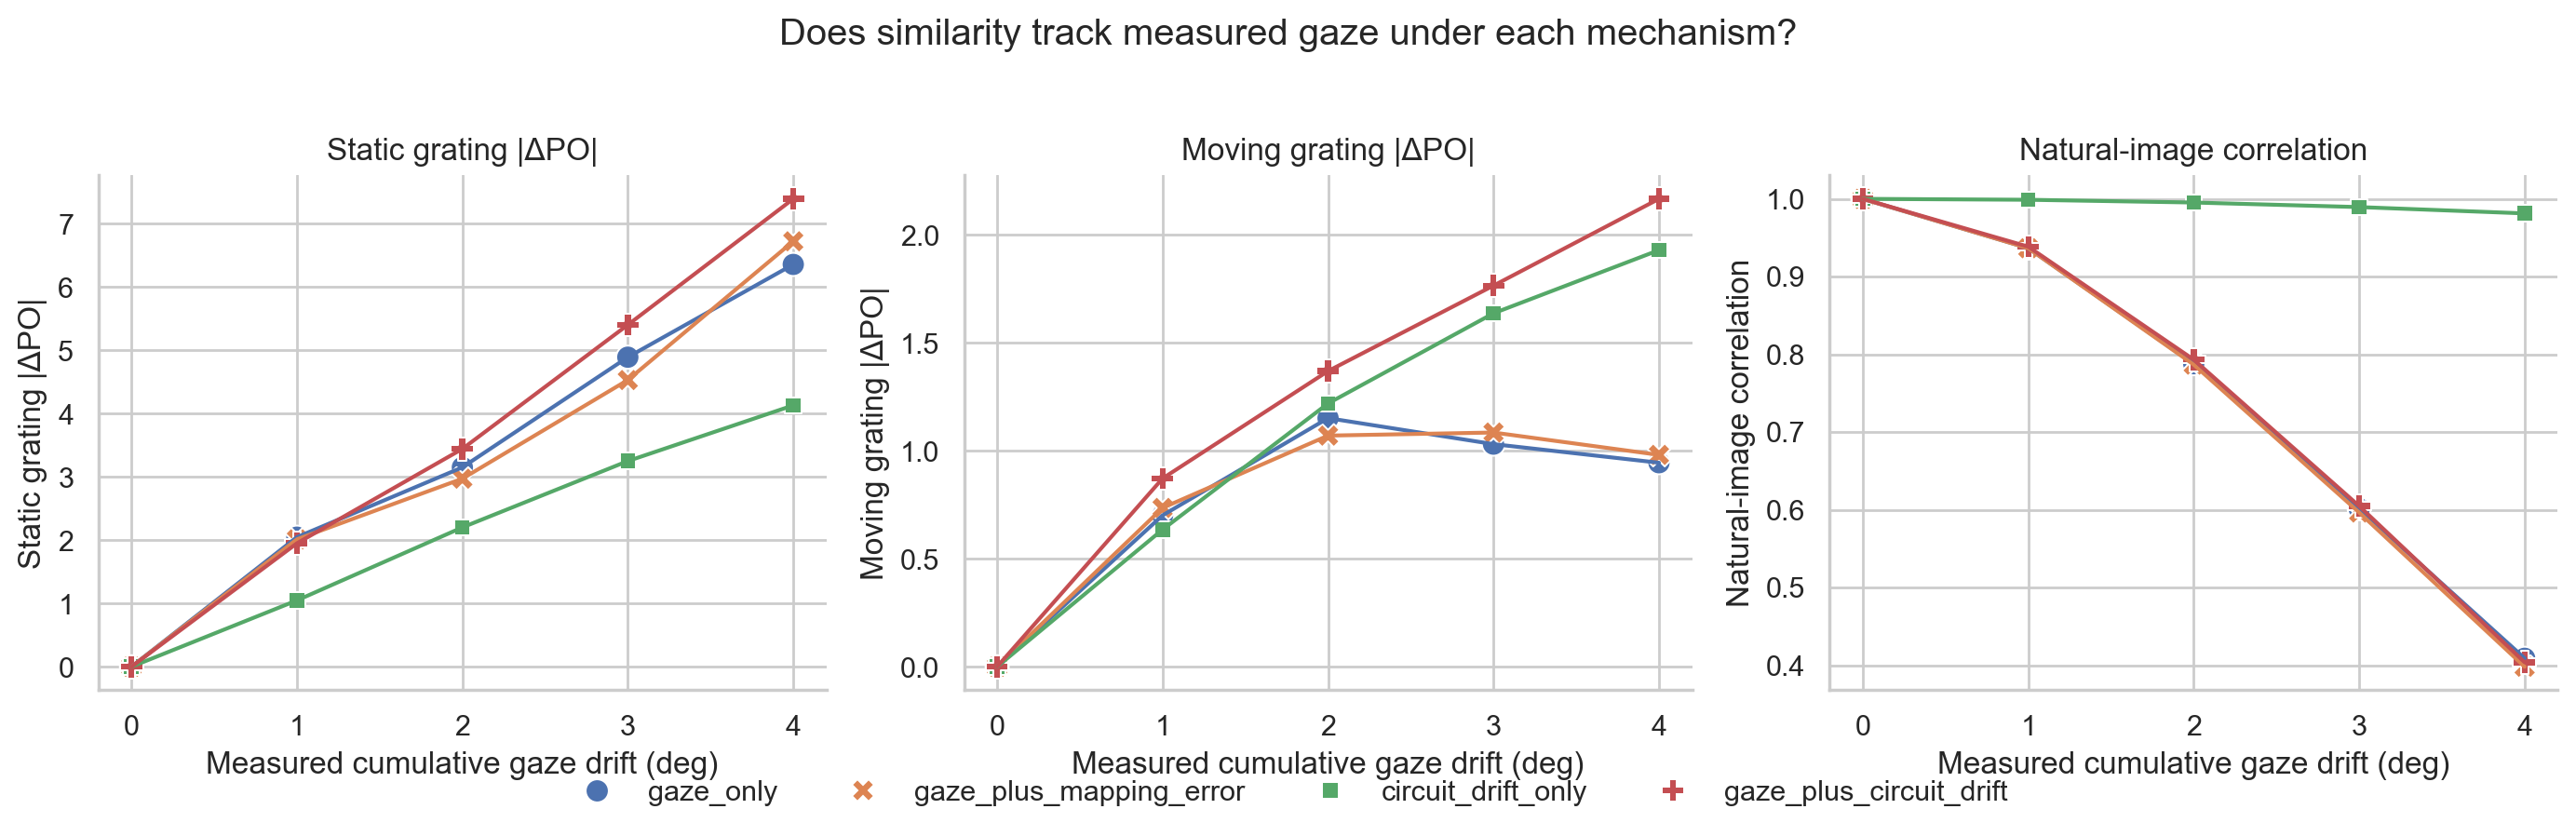

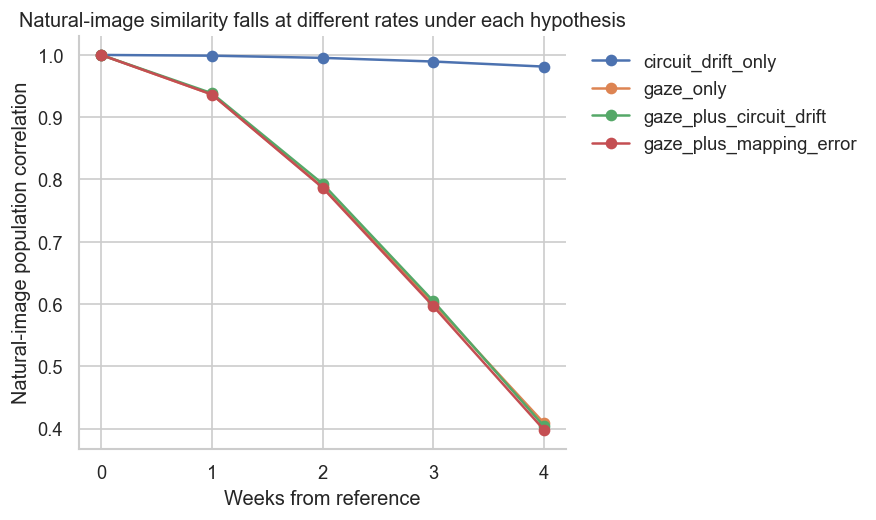

In [8]:
display(Image(filename=ROOT / 'results/figures/primary_12_longitudinal_hypothesis_panels.png'))
display(Image(filename=ROOT / 'results/figures/primary_13_longitudinal_gaze_vs_similarity.png'))

trajectory = longitudinal.pivot(index='weeks_from_reference', columns='condition', values='natural_population_response_correlation')
ax = trajectory.plot(figsize=(7.5, 4.5), marker='o')
ax.set_xlabel('Weeks from reference')
ax.set_ylabel('Natural-image population correlation')
ax.set_title('Natural-image similarity falls at different rates under each hypothesis')
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()